<a href="https://colab.research.google.com/github/tasneem2003mo/color-recognition-pink-/blob/main/color_recognition(pink).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Screenshot 2026-07-19 184152.png to Screenshot 2026-07-19 184152.png
--- النتيجة النهائية المرتبة ---


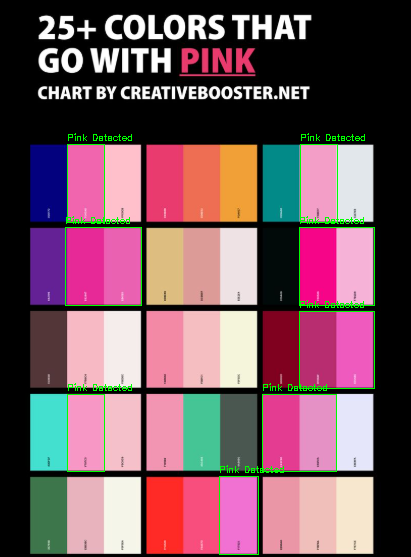

In [7]:
import cv2
import numpy as np
from google.colab import files
from google.colab.patches import cv2_imshow

# 1. رفع الصورة
uploaded = files.upload()
file_name = list(uploaded.keys())[0]

# 2. قراءة الصورة
frame = cv2.imread(file_name)

# 3. تحويل الألوان وتحديد النطاق الوردي
hsv_frame = cv2.cvtColor(frame, cv2.COLOR_BGR2HSV)
lower_pink = np.array([140, 50, 50])
upper_pink = np.array([170, 255, 255])
pink_mask = cv2.inRange(hsv_frame, lower_pink, upper_pink)

# 4. البحث عن اللون الوردي ورسم المستطيل
contours, _ = cv2.findContours(pink_mask, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

for contour in contours:
    area = cv2.contourArea(contour)
    if area > 100: # تقليل المساحة لتناسب المربعات الصغيرة
        x, y, w, h = cv2.boundingRect(contour)
        # جعل سمك المستطيل 1 بدلاً من 3 لتصبح الخطوط نحيفة ومحددة
        cv2.rectangle(frame, (x, y), (x + w, y + h), (0, 255, 0), 1)
        # تصغير حجم الخط إلى 0.3 وسماكته إلى 1 ليكون الكلام صغيراً ومرتباً
        cv2.putText(frame, "Pink Detected", (x, y - 4),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.3, (0, 255, 0), 1)

# 5. عرض الصورة الناتجة
print("--- النتيجة النهائية المرتبة ---")
cv2_imshow(frame)